# Credit Risk Model — Corrected Notebook

This version fixes preprocessing, feature order, model comparison, saving artifacts, and SHAP setup.

In [1]:
import os
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available:", e)

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP not available:", e)

os.makedirs("models", exist_ok=True)
os.makedirs("dataset", exist_ok=True)
os.makedirs("reports", exist_ok=True)


## 1. Load dataset

Change `DATA_PATH` according to your system. Avoid hard-coding Windows paths when deploying.

In [2]:
DATA_PATH = "C:/Users/senan/Downloads/credit_risk_dataset/credit_train.csv"  # Put credit_train.csv in the same folder as this notebook, or update this path

df_credit = pd.read_csv(DATA_PATH)
df_credit.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Basic checks

In [3]:
print("Dataset Shape:", df_credit.shape)
print(df_credit.columns.tolist())
print("\nMissing values:")
print(df_credit.isnull().sum())
print("\nTarget distribution:")
print(df_credit["Loan_Status"].value_counts())


Dataset Shape: (614, 13)
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Target distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


## 3. Cleaning

In [4]:
df_credit = df_credit.drop_duplicates()

if "Loan_ID" in df_credit.columns:
    df_credit = df_credit.drop("Loan_ID", axis=1)

for col in df_credit.columns:
    if df_credit[col].dtype == "object":
        df_credit[col] = df_credit[col].fillna(df_credit[col].mode()[0])
    else:
        df_credit[col] = df_credit[col].fillna(df_credit[col].median())

# Target mapping: Approved = 1, Rejected = 0
df_credit["Loan_Status"] = df_credit["Loan_Status"].map({"Y": 1, "N": 0})

print(df_credit.isnull().sum())
print(df_credit["Loan_Status"].value_counts())


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
Loan_Status
1    422
0    192
Name: count, dtype: int64


## 4. Encode categorical features

In [5]:
label_encoders = {}

for col in df_credit.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_credit[col] = le.fit_transform(df_credit[col])
    label_encoders[col] = le

joblib.dump(label_encoders, "models/credit_label_encoders.pkl")

df_credit.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## 5. Feature engineering

Income may look less important if used raw. Log income and debt-to-income ratio usually make it more meaningful.

In [6]:
df_credit["Total_Income"] = df_credit["ApplicantIncome"] + df_credit["CoapplicantIncome"]
df_credit["Total_Income_Log"] = np.log1p(df_credit["Total_Income"])
df_credit["LoanAmount_Log"] = np.log1p(df_credit["LoanAmount"])
df_credit["Debt_Income_Ratio"] = df_credit["LoanAmount"] / (df_credit["Total_Income"] + 1)

credit_feature_columns = [
    "Credit_History",
    "Total_Income_Log",
    "LoanAmount_Log",
    "Debt_Income_Ratio",
    "Married",
    "Education",
    "Property_Area"
]

X_credit = df_credit[credit_feature_columns].copy()
y_credit = df_credit["Loan_Status"].copy()

print("Features:", X_credit.shape)
print("Target:", y_credit.shape)
print(X_credit.columns.tolist())


Features: (614, 7)
Target: (614,)
['Credit_History', 'Total_Income_Log', 'LoanAmount_Log', 'Debt_Income_Ratio', 'Married', 'Education', 'Property_Area']


## 6. Train-test split

Important: split first, then scale. Scaling before splitting causes data leakage.

In [7]:
X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

credit_scaler = StandardScaler()
X_credit_train_scaled = credit_scaler.fit_transform(X_credit_train)
X_credit_test_scaled = credit_scaler.transform(X_credit_test)

X_credit_train_scaled = pd.DataFrame(X_credit_train_scaled, columns=credit_feature_columns, index=X_credit_train.index)
X_credit_test_scaled = pd.DataFrame(X_credit_test_scaled, columns=credit_feature_columns, index=X_credit_test.index)


## 7. Train models

In [8]:
credit_log = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
credit_log.fit(X_credit_train_scaled, y_credit_train)

credit_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)
credit_rf.fit(X_credit_train, y_credit_train)

models = {
    "Logistic Regression": (credit_log, X_credit_test_scaled),
    "Random Forest": (credit_rf, X_credit_test)
}

if XGBOOST_AVAILABLE:
    credit_xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    credit_xgb.fit(X_credit_train, y_credit_train)
    models["XGBoost"] = (credit_xgb, X_credit_test)


## 8. Model evaluation

In [9]:
credit_results = []

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    credit_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_credit_test, y_pred),
        "Precision": precision_score(y_credit_test, y_pred),
        "Recall": recall_score(y_credit_test, y_pred),
        "F1 Score": f1_score(y_credit_test, y_pred),
        "ROC-AUC": roc_auc_score(y_credit_test, y_prob)
    })

    print("\n" + "="*60)
    print(name)
    print(classification_report(y_credit_test, y_pred))

credit_results_df = pd.DataFrame(credit_results).sort_values(by="F1 Score", ascending=False)
credit_results_df



Logistic Regression
              precision    recall  f1-score   support

           0       0.71      0.66      0.68        38
           1       0.85      0.88      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.77      0.78       123
weighted avg       0.81      0.81      0.81       123


Random Forest
              precision    recall  f1-score   support

           0       0.78      0.76      0.77        38
           1       0.90      0.91      0.90        85

    accuracy                           0.86       123
   macro avg       0.84      0.83      0.84       123
weighted avg       0.86      0.86      0.86       123


XGBoost
              precision    recall  f1-score   support

           0       0.85      0.74      0.79        38
           1       0.89      0.94      0.91        85

    accuracy                           0.88       123
   macro avg       0.87      0.84      0.85       123
weighted avg       0.88      

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.878049,0.888889,0.941176,0.914286,0.863777
1,Random Forest,0.861789,0.895349,0.905882,0.900585,0.877399
0,Logistic Regression,0.813008,0.852273,0.882353,0.867052,0.862539


## 9. Feature importance

In [11]:
rf_importance = pd.DataFrame({
    "Feature": credit_feature_columns,
    "Importance": credit_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:")
display(rf_importance)

coef_df = pd.DataFrame({
    "Feature": credit_feature_columns,
    "Coefficient": credit_log.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Logistic Regression Coefficients:")
display(coef_df)

xgb_importance = pd.DataFrame({
    "Feature": credit_feature_columns,
    "Importance": credit_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("XGBoost Feature Importance:")
display(xgb_importance)


Random Forest Feature Importance:


,Feature,Importance
0,Credit_History,0.439003
3,Debt_Income_Ratio,0.165387
1,Total_Income_Log,0.154196
2,LoanAmount_Log,0.148041
6,Property_Area,0.048849
4,Married,0.024649
5,Education,0.019875


Logistic Regression Coefficients:


,Feature,Coefficient
0,Credit_History,1.223013
2,LoanAmount_Log,0.279885
4,Married,0.267936
6,Property_Area,0.047752
5,Education,-0.177482
3,Debt_Income_Ratio,-0.286771
1,Total_Income_Log,-0.426001


XGBoost Feature Importance:


,Feature,Importance
0,Credit_History,0.558050
5,Education,0.076778
4,Married,0.076275
6,Property_Area,0.074399
1,Total_Income_Log,0.072930
3,Debt_Income_Ratio,0.072650
2,LoanAmount_Log,0.068918


## 10. SHAP explanation

Use TreeExplainer for Random Forest/XGBoost. This is better than using logistic regression for your Model Insights tab.

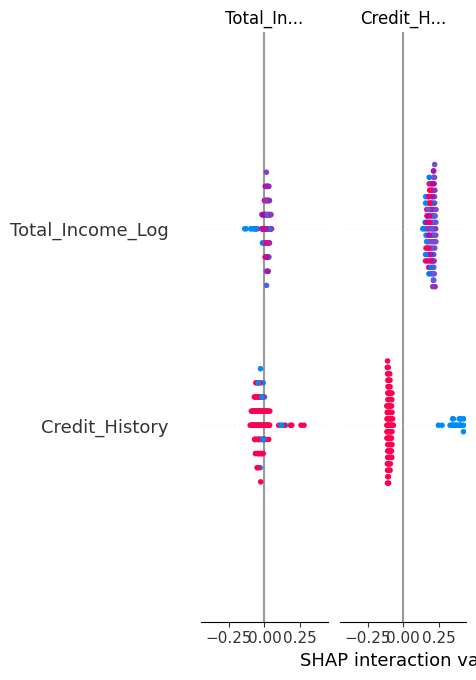

In [16]:
if SHAP_AVAILABLE:
    # Choose your final model for SHAP
    final_model = credit_rf
    X_shap = X_credit_test.copy()

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_shap)

    # For binary RandomForest, shap_values may be a list [class_0, class_1]
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values_to_plot = shap_values

    shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar")
else:
    print("Install SHAP using: pip install shap")


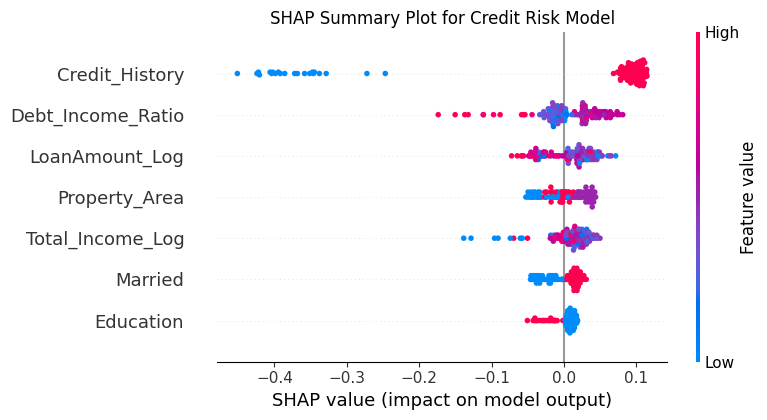

In [47]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs("reports", exist_ok=True)

X_shap = pd.DataFrame(X_credit_test, columns=credit_feature_columns)

explainer = shap.TreeExplainer(credit_rf)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_class1,
    X_shap,
    feature_names=credit_feature_columns,
    max_display=len(credit_feature_columns),
    show=False
)

plt.title("SHAP Summary Plot for Credit Risk Model")
plt.tight_layout()

plt.savefig(
    "reports/credit_shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

## 11. Save final artifacts

Use Random Forest as the default final model here. You can change to XGBoost if it performs better.

In [22]:
final_credit_model = credit_rf

joblib.dump(final_credit_model, "models/credit_risk_model.pkl")
joblib.dump(credit_scaler, "models/credit_scaler.pkl")
joblib.dump(credit_feature_columns, "models/credit_feature_columns.pkl")

df_credit.to_csv("dataset/credit_risk_processed.csv", index=False)
credit_results_df.to_csv("reports/credit_model_results.csv", index=False)

print("Saved:")
print("models/credit_risk_model.pkl")
print("models/credit_scaler.pkl")
print("models/credit_feature_columns.pkl")
print("models/credit_label_encoders.pkl")
print("dataset/credit_risk_processed.csv")
print("reports/credit_model_results.csv")


Saved:
models/credit_risk_model.pkl
models/credit_scaler.pkl
models/credit_feature_columns.pkl
models/credit_label_encoders.pkl
dataset/credit_risk_processed.csv
reports/credit_model_results.csv


## 12. Prediction helper for Streamlit

In [23]:
def prepare_credit_input(raw_input_df, label_encoders, feature_columns):
    data = raw_input_df.copy()

    for col, le in label_encoders.items():
        if col in data.columns:
            data[col] = le.transform(data[col])

    data["Total_Income"] = data["ApplicantIncome"] + data["CoapplicantIncome"]
    data["Total_Income_Log"] = np.log1p(data["Total_Income"])
    data["LoanAmount_Log"] = np.log1p(data["LoanAmount"])
    data["Debt_Income_Ratio"] = data["LoanAmount"] / (data["Total_Income"] + 1)

    return data[feature_columns]

# Example:
# user_df = pd.DataFrame([{
#     "Gender": "Male",
#     "Married": "Yes",
#     "Dependents": "0",
#     "Education": "Graduate",
#     "Self_Employed": "No",
#     "ApplicantIncome": 5000,
#     "CoapplicantIncome": 0,
#     "LoanAmount": 150,
#     "Loan_Amount_Term": 360,
#     "Credit_History": 1.0,
#     "Property_Area": "Urban"
# }])
#
# X_user = prepare_credit_input(user_df, label_encoders, credit_feature_columns)
# prediction = final_credit_model.predict(X_user)[0]
# probability = final_credit_model.predict_proba(X_user)[0][1]
# print(prediction, probability)


In [42]:
user_df = pd.DataFrame([{
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "0",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 8000,
    "CoapplicantIncome": 3000,
    "LoanAmount": 70,
    "Loan_Amount_Term": 360,
    "Credit_History": 1.0,
    "Property_Area": "Urban"
}])

X_user = prepare_credit_input(user_df, label_encoders, credit_feature_columns)

prediction = final_credit_model.predict(X_user)[0]
probability = final_credit_model.predict_proba(X_user)[0]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 1
Probability: [0.38717939 0.61282061]


In [26]:
df_credit["Total_Income"] = df_credit["ApplicantIncome"] + df_credit["CoapplicantIncome"]

df_credit["Total_Income"].describe()

count      614.000000
mean      7024.705081
std       6458.663872
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: Total_Income, dtype: float64